# Sales Data Cleaning & Analysis Project

## Overview
This project focuses on cleaning, analyzing, and visualizing sales data to uncover business insights related to sales performance, profitability, and shipping efficiency.

## Tools Used
- Python (Pandas, NumPy)
- Matplotlib / Seaborn
- Google Colab


In [3]:
import numpy as np
import pandas as pd

In [4]:
from google.colab import files
uploaded=files.upload()

Saving train.csv to train.csv


## Business Problem

The dataset contains raw sales transactions with missing values, duplicates, and inconsistent formats.

### Business Questions
- Which regions generate the highest sales and profit?
- Which product categories are most profitable?
- How does sales performance change over time?
- Are there shipping delays that may affect operations?


In [5]:

df = pd.read_csv('/content/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Data Cleaning Approach

The following steps were taken to improve data quality:
- Removed duplicate records
- Converted date columns to proper datetime format
- Handled missing values carefully to avoid unnecessary data loss
- Standardized text fields for consistency
- Created new analytical columns


In [8]:
df = df.drop_duplicates()


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

In [10]:
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Postal Code'] = pd.to_numeric(df['Postal Code'], errors='coerce')

In [11]:
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['nan', 'None', 'NONE', '', 'NaN'], np.nan)

In [12]:
columns_to_standardize = ['Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Ship Mode']
for col in columns_to_standardize:
    if col in df.columns:
        df[col] = df[col].str.title()

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_val)

In [15]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [16]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter

In [17]:
df['Shipping Days'] = df['Shipping Days'].apply(lambda x: max(0, x) if pd.notnull(x) else x)

## Data Quality Check

After cleaning:
- Duplicate records were removed
- Missing values were handled safely
- Date and numeric columns were validated

The cleaned dataset is now ready for analysis.


In [18]:
df.to_csv('train_cleaned.csv', index=False)

print("Cleaning completed. Saved as 'train_cleaned.csv'")
print(f"Original shape: {pd.read_csv('train.csv').shape}")
print(f"Cleaned shape: {df.shape}")

Cleaning completed. Saved as 'train_cleaned.csv'
Original shape: (9800, 18)
Cleaned shape: (9800, 22)


In [19]:
df.isnull()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days,Order Year,Order Month,Order Quarter
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9796,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9797,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9798,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Feature Engineering

New features were created to support deeper analysis:
- Year, Month, and Quarter for time-based analysis
- Profit Margin to measure profitability
- Shipping Days to analyze delivery efficiency


In [22]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month_name()
df['quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

# df['profit_margin'] = df['Profit'] / df['Sales'] # 'Profit' column does not exist

df['shipping_days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load cleaned data
df = pd.read_csv('train_cleaned.csv')

# Convert dates if needed
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Dataset shape: (9800, 22)
Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


## Exploratory Data Analysis (EDA)


## Exploratory Data Analysis (EDA)

The purpose of this section is to explore sales performance, profitability, and trends using visual analysis to answer the business questions defined earlier.


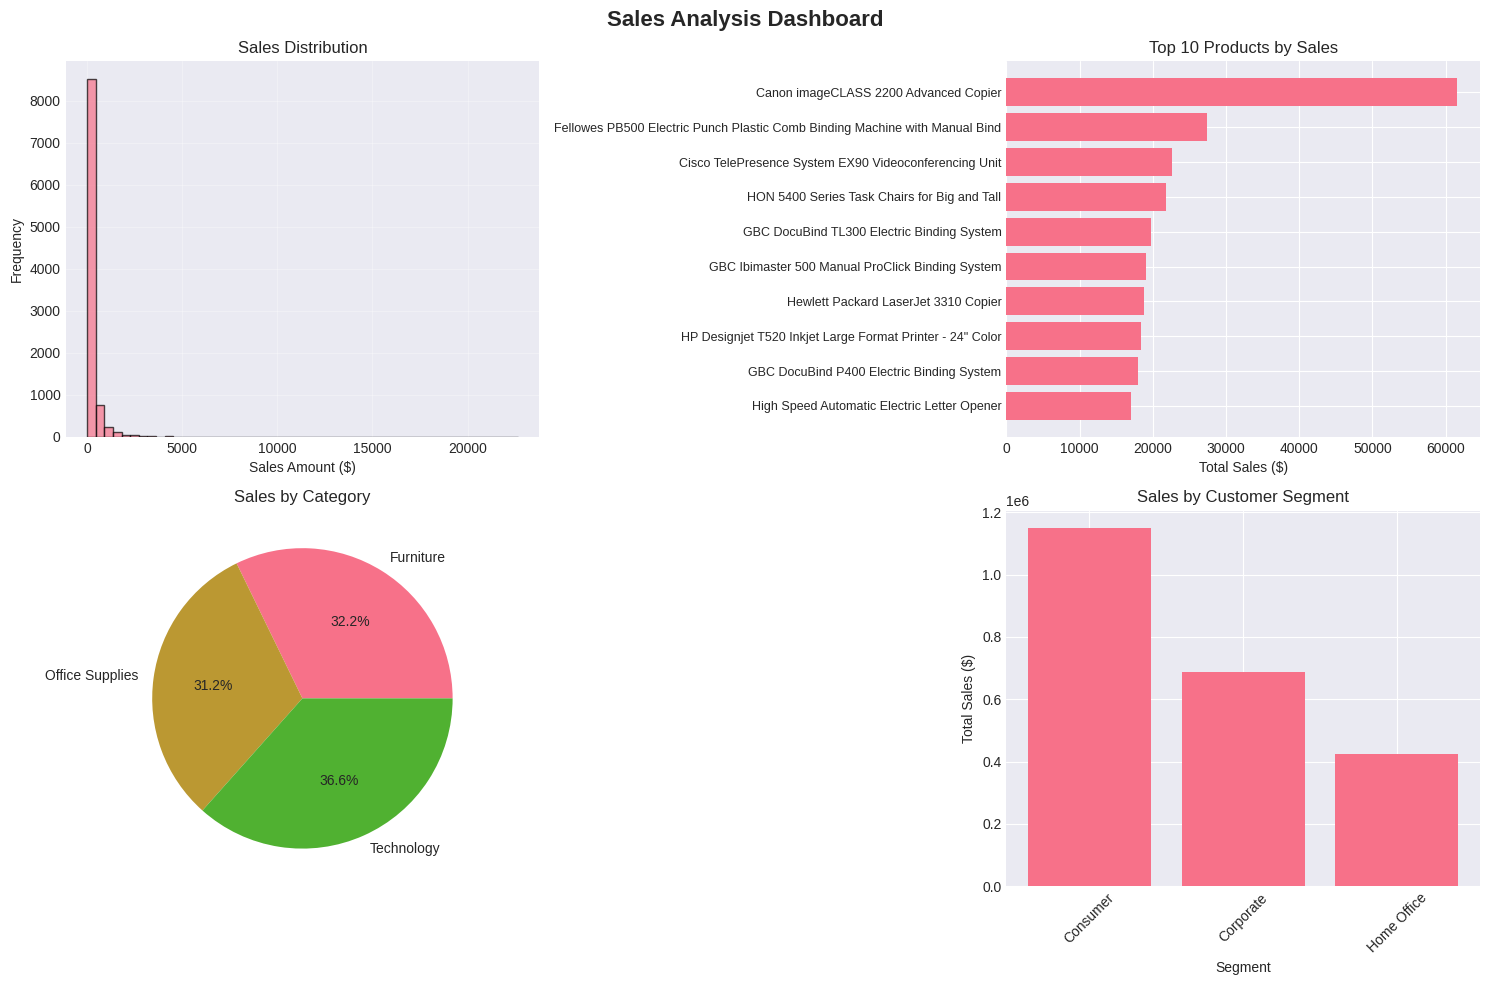

In [24]:
# Create figure for sales analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sales Analysis Dashboard', fontsize=16, fontweight='bold')
# 1. Sales distribution histogram
axes[0, 0].hist(df['Sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Sales Distribution')
axes[0, 0].set_xlabel('Sales Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
axes[0, 1].barh(range(len(top_products)), top_products.values)
axes[0, 1].set_yticks(range(len(top_products)))
axes[0, 1].set_yticklabels(top_products.index, fontsize=9)
axes[0, 1].set_title('Top 10 Products by Sales')
axes[0, 1].set_xlabel('Total Sales ($)')
axes[0, 1].invert_yaxis()

# 3. Sales by category
category_sales = df.groupby('Category')['Sales'].sum()
axes[1, 0].pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%')
axes[1, 0].set_title('Sales by Category')

# 4. Sales by segment
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1, 1].bar(segment_sales.index, segment_sales.values)
axes[1, 1].set_title('Sales by Customer Segment')
axes[1, 1].set_xlabel('Segment')
axes[1, 1].set_ylabel('Total Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



#### Insight
- The West region generates the highest total sales.
- Some regions show lower sales performance.

#### Business Recommendation
- Allocate more resources to high-performing regions.
- Investigate demand and logistics in low-performing regions.


### Monthly Sales Trend

This analysis evaluates how total sales change over time on a monthly basis to identify growth patterns, seasonality, and potential peak or low-performing periods.


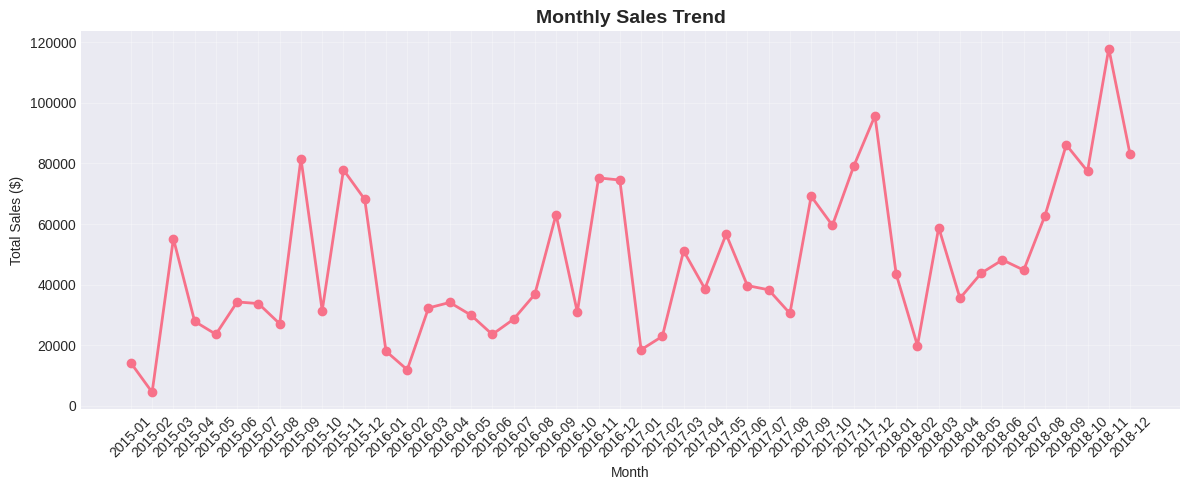

In [25]:
# Create monthly sales trend
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Order Month'], monthly_sales['Sales'], marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

#### Insight
- Sales show noticeable fluctuations across different months.
- Certain months experience clear peaks, indicating strong seasonal demand.
- Periods of lower sales suggest off-peak seasons or reduced customer activity.

#### Business Recommendation
- Increase inventory and marketing efforts before peak months.
- Plan promotions or discounts during low-performing months to stabilize revenue.
- Use historical monthly trends to improve demand forecasting and budgeting.


## Sales by Region

This analysis examines how sales are distributed across different regions.


### Top 15 States by Sales

This analysis identifies the top-performing states based on total sales, helping understand geographic concentration of revenue and key regional markets.


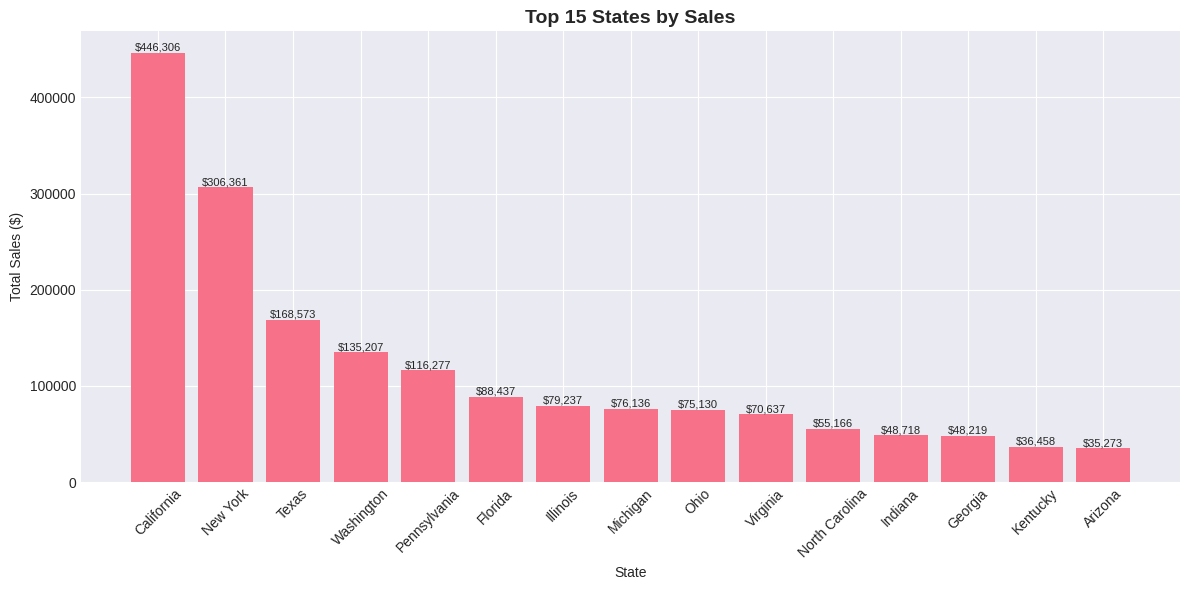

In [26]:
# Top states by sales
state_sales = df.groupby('State')['Sales'].sum().nlargest(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(state_sales.index, state_sales.values)
plt.title('Top 15 States by Sales', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('state_sales.png', dpi=300, bbox_inches='tight')
plt.show()

#### Insight
- Sales are heavily concentrated in a small number of states.
- The top few states contribute a significant portion of total revenue.
- Lower-ranked states show comparatively smaller sales volumes.

#### Business Recommendation
- Prioritize marketing and customer retention strategies in high-performing states.
- Analyze factors driving success in top states and replicate them in underperforming regions.
- Optimize distribution and inventory allocation based on state-level demand.


### Shipping Mode Distribution

This analysis shows the proportion of orders shipped using each shipping mode, helping understand customer delivery preferences.


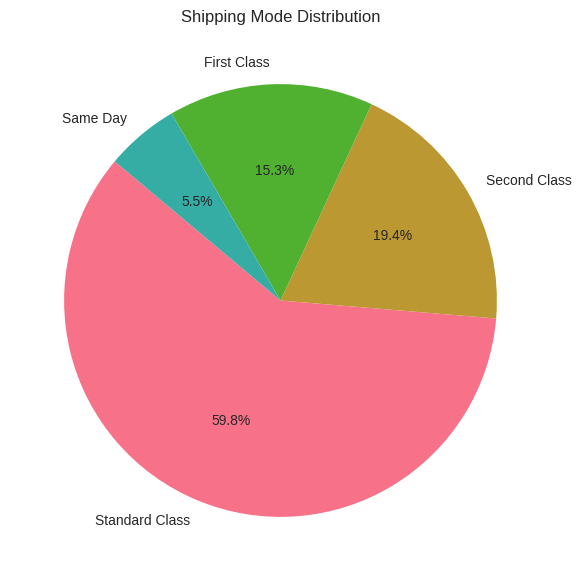

In [34]:
# Shipping mode distribution
ship_mode_counts = df['Ship Mode'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    ship_mode_counts.values,
    labels=ship_mode_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Shipping Mode Distribution')
plt.tight_layout()
plt.savefig('shipping_mode_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


#### Insight
- Standard Class dominates the shipping preferences.
- Faster shipping options are used less frequently.

#### Business Recommendation
- Maintain cost-efficient logistics for standard shipping.
- Offer targeted promotions for faster shipping options to increase adoption.


### Sales by Shipping Mode

This analysis evaluates how different shipping modes contribute to total sales revenue.


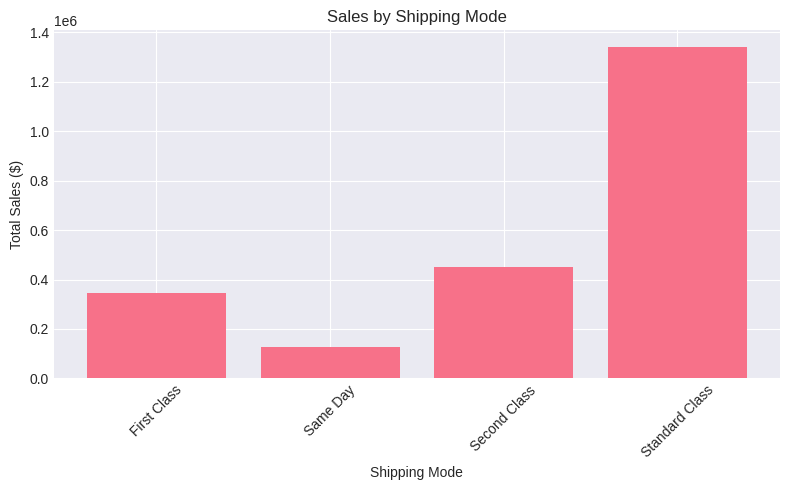

In [35]:
# Sales by shipping mode
ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(8, 5))
plt.bar(ship_mode_sales.index, ship_mode_sales.values)
plt.title('Sales by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_shipping_mode.png', dpi=300, bbox_inches='tight')
plt.show()


#### Insight
- Expedited shipping modes generate a high share of revenue.
- Customers choosing faster delivery tend to place higher-value orders.

#### Business Recommendation
- Encourage premium shipping for high-value purchases.
- Align shipping strategy with revenue optimization goals.


### Top 10 Customers by Sales

This analysis identifies the highest-value customers based on total sales to understand revenue concentration and customer importance.


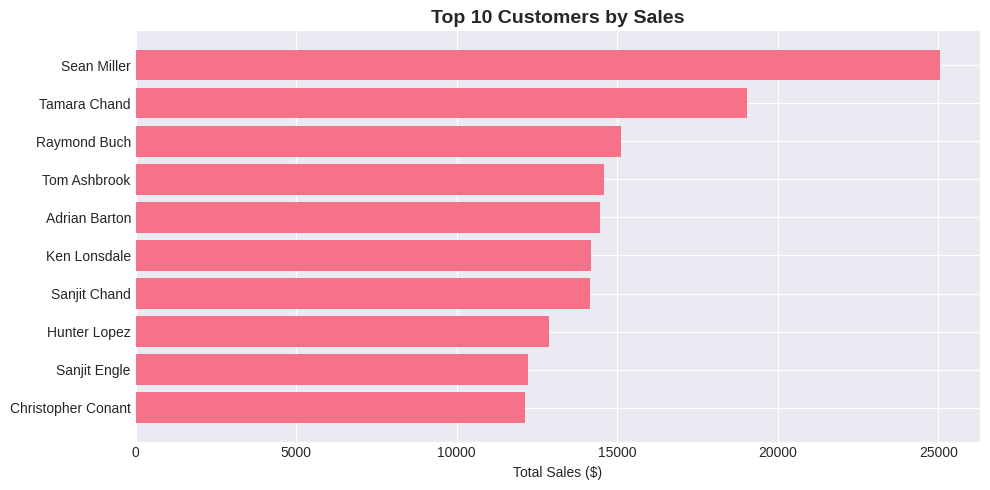

In [28]:
# Customer analysis
plt.figure(figsize=(10, 5))

# Top customers by sales
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10)

plt.barh(range(len(top_customers)), top_customers.values)
plt.yticks(range(len(top_customers)), top_customers.index)
plt.title('Top 10 Customers by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('top_customers.png', dpi=300, bbox_inches='tight')
plt.show()

#### Insight
- A small number of customers contribute a significant portion of total sales.
- There is a noticeable gap between the top customers and the rest, indicating revenue concentration.

#### Business Recommendation
- Develop loyalty and retention programs for high-value customers.
- Provide personalized offers or dedicated account management for top customers.
- Reduce revenue risk by expanding acquisition efforts for mid-tier customers.


### Sales by Sub-Category

This analysis examines sales performance across different product sub-categories to identify high- and low-performing product lines.


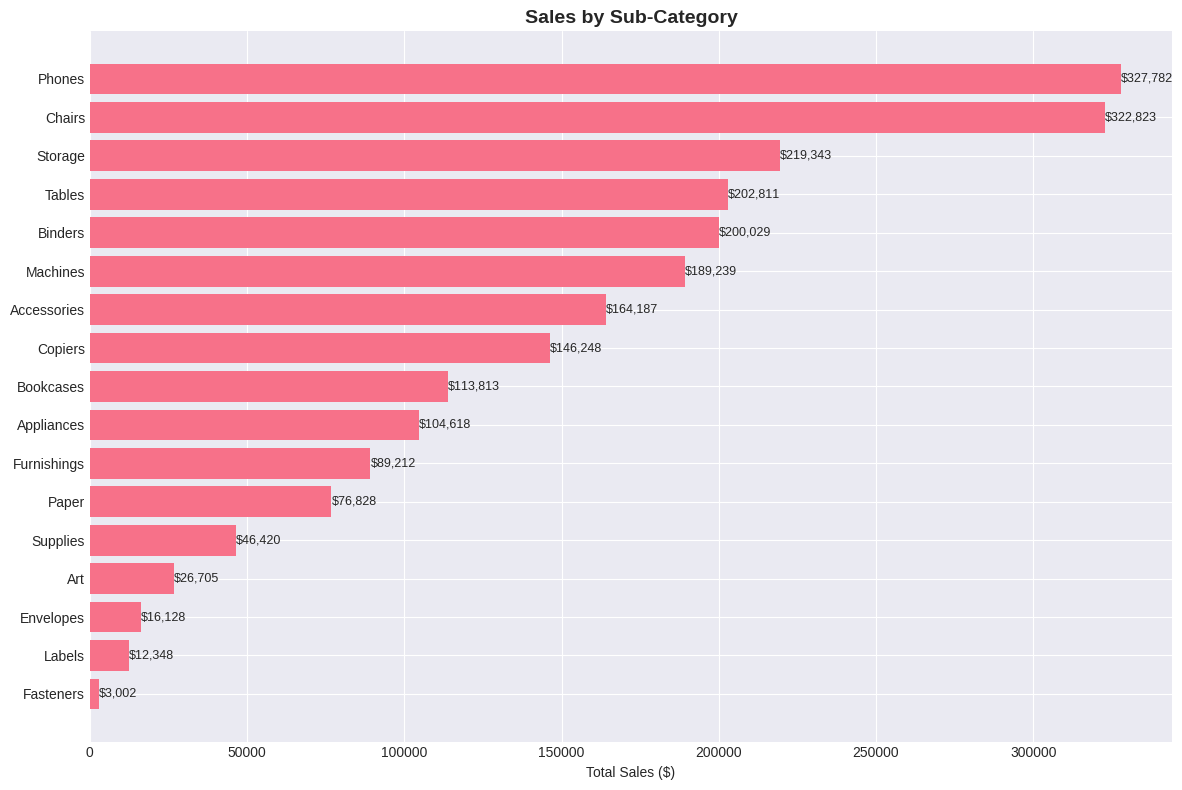

In [29]:
# Sub-category analysis
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(subcategory_sales)), subcategory_sales.values)
plt.yticks(range(len(subcategory_sales)), subcategory_sales.index)
plt.title('Sales by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'${width:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('subcategory_sales.png', dpi=300, bbox_inches='tight')
plt.show()

#### Insight
- Sales vary significantly across sub-categories.
- A few sub-categories contribute the majority of revenue, while others underperform.
- Lower-performing sub-categories may indicate low demand or pricing issues.

####Business Recommendation
- Focus inventory and marketing efforts on high-performing sub-categories.
- Review pricing, promotion, or product relevance for underperforming sub-categories.
- Consider discontinuing or repositioning consistently low-performing products.


#Feature Correlation Heatmap

This analysis examines relationships between numeric features in the dataset to identify strong positive or negative correlations.
Understanding these correlations helps detect redundant features, guide feature selection, and spot potential multicollinearity issues.

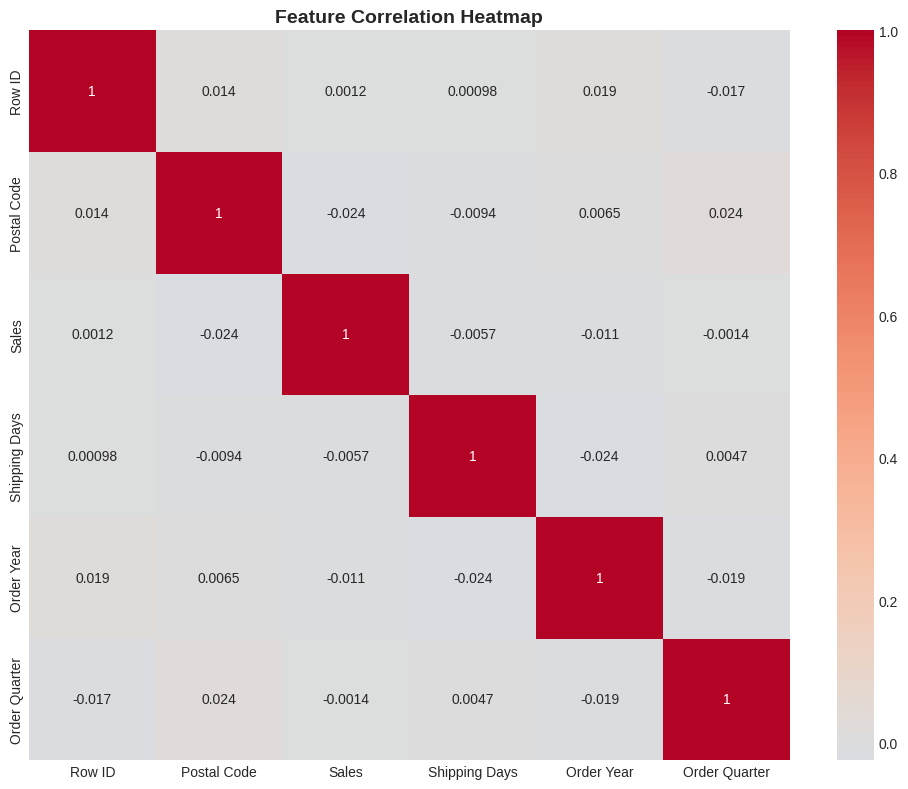

In [30]:
# Prepare data for correlation
numeric_df = df.select_dtypes(include=[np.number])

if len(numeric_df.columns) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

####Insight



*   Some features show strong positive correlations, suggesting redundancy.

*   Features with strong negative correlations indicate inverse  relationships that may impact modeling.

*   Weakly correlated features are likely independent and can provide unique information.

###Business Recommendation

* Consider removing or combining highly correlated features to simplify models.

* Use negative correlations to understand trade-offs between features.

* Retain weakly correlated features that add independent value to predictive models.

#Complete Sales Visualization Dashboard

This dashboard provides a comprehensive view of the sales data across multiple dimensions, including trends over time, performance by category, segment, and region, as well as top products and shipping distribution.
It helps identify key drivers of revenue, high-performing areas, and opportunities for operational or marketing improvements.

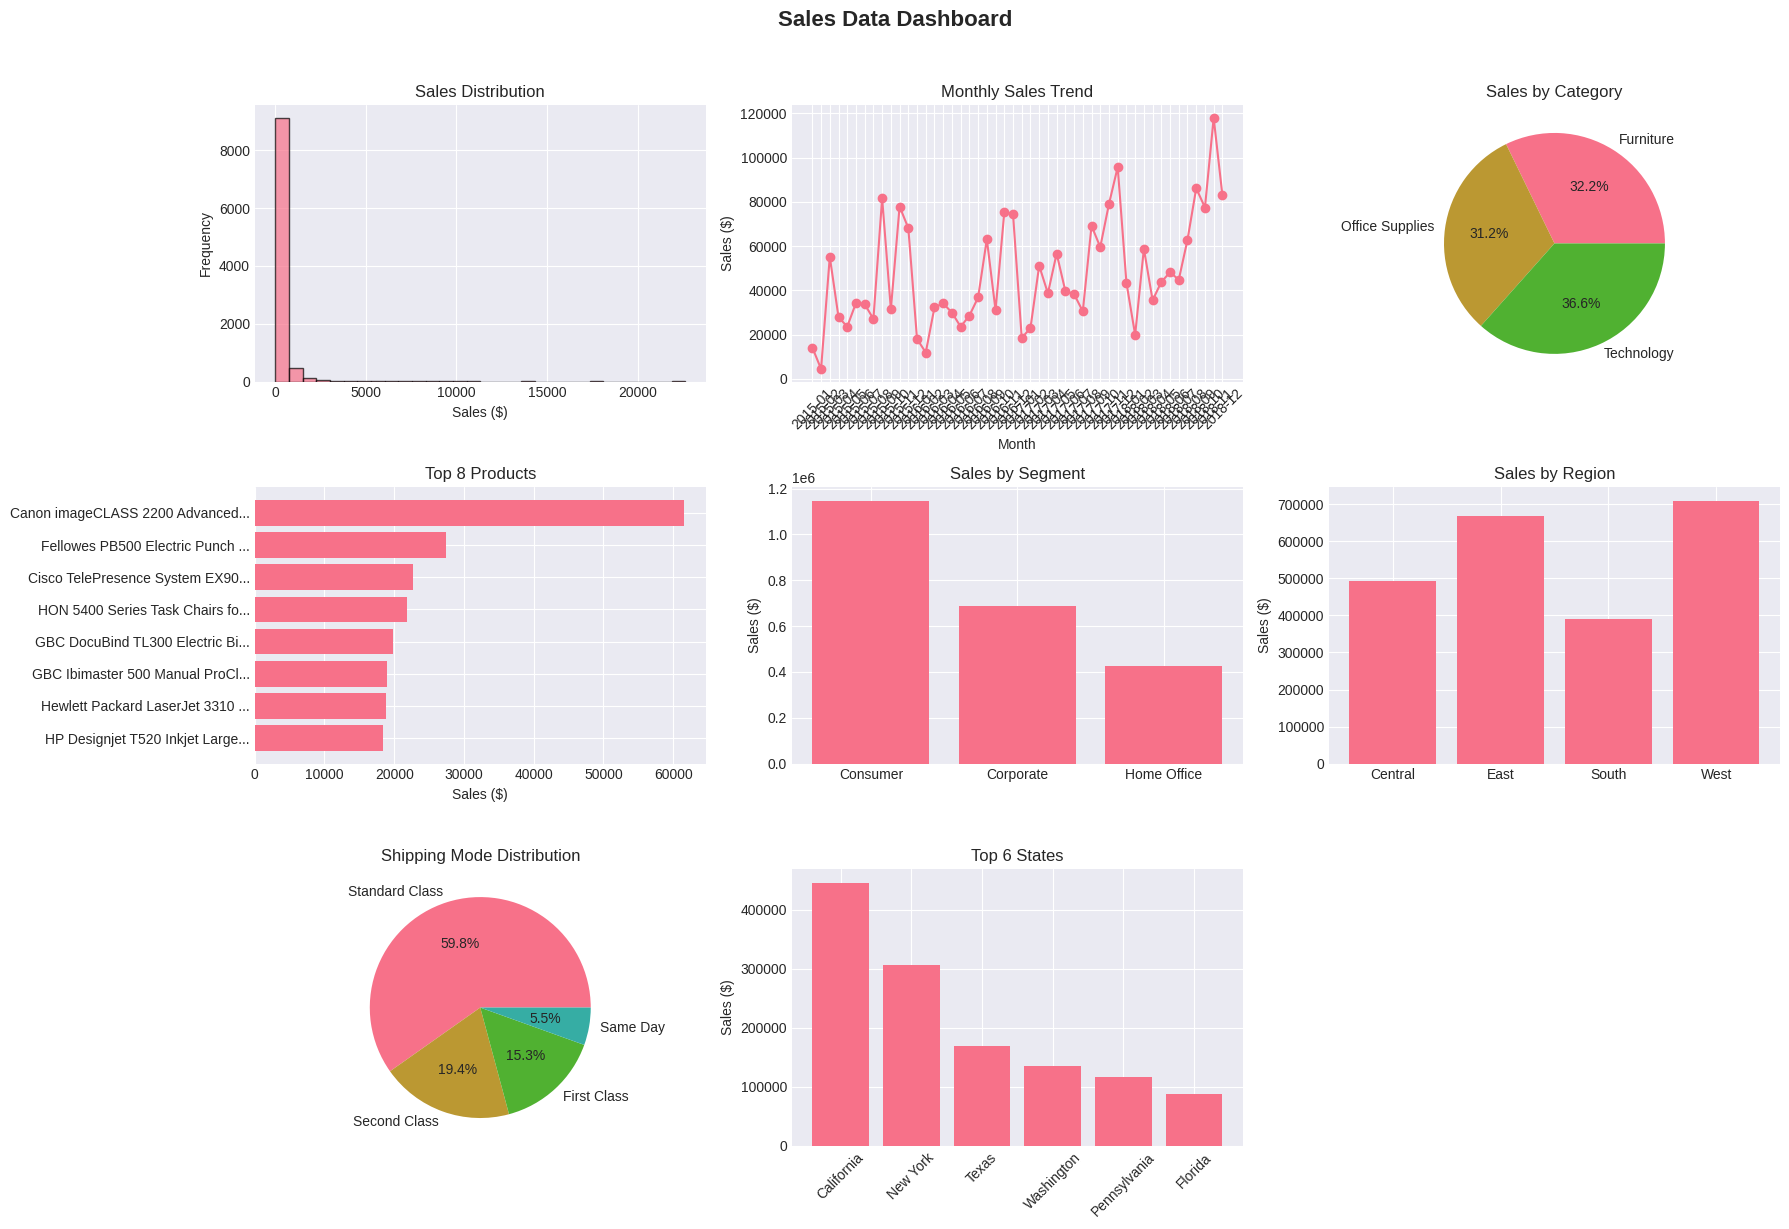

In [31]:
# COMPLETE VISUALIZATION DASHBOARD
def create_dashboard(df):
    """Create a complete visualization dashboard"""

    fig = plt.figure(figsize=(18, 12))

    # 1. Sales Distribution
    ax1 = plt.subplot(3, 3, 1)
    ax1.hist(df['Sales'], bins=30, edgecolor='black', alpha=0.7)
    ax1.set_title('Sales Distribution')
    ax1.set_xlabel('Sales ($)')
    ax1.set_ylabel('Frequency')

    # 2. Monthly Sales Trend
    ax2 = plt.subplot(3, 3, 2)
    monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
    ax2.plot(monthly.index.astype(str), monthly.values, marker='o')
    ax2.set_title('Monthly Sales Trend')
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Sales ($)')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    # 3. Sales by Category
    ax3 = plt.subplot(3, 3, 3)
    category_sales = df.groupby('Category')['Sales'].sum()
    ax3.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%')
    ax3.set_title('Sales by Category')

    # 4. Top Products
    ax4 = plt.subplot(3, 3, 4)
    top_products = df.groupby('Product Name')['Sales'].sum().nlargest(8)
    ax4.barh(range(len(top_products)), top_products.values)
    ax4.set_yticks(range(len(top_products)))
    ax4.set_yticklabels([p[:30] + '...' if len(p) > 30 else p for p in top_products.index])
    ax4.set_title('Top 8 Products')
    ax4.set_xlabel('Sales ($)')
    ax4.invert_yaxis()

    # 5. Sales by Segment
    ax5 = plt.subplot(3, 3, 5)
    segment_sales = df.groupby('Segment')['Sales'].sum()
    ax5.bar(segment_sales.index, segment_sales.values)
    ax5.set_title('Sales by Segment')
    ax5.set_ylabel('Sales ($)')

    # 6. Sales by Region
    ax6 = plt.subplot(3, 3, 6)
    region_sales = df.groupby('Region')['Sales'].sum()
    ax6.bar(region_sales.index, region_sales.values)
    ax6.set_title('Sales by Region')
    ax6.set_ylabel('Sales ($)')

    # 7. Shipping Mode
    ax7 = plt.subplot(3, 3, 7)
    ship_counts = df['Ship Mode'].value_counts()
    ax7.pie(ship_counts.values, labels=ship_counts.index, autopct='%1.1f%%')
    ax7.set_title('Shipping Mode Distribution')

    # 8. Top States
    ax8 = plt.subplot(3, 3, 8)
    top_states = df.groupby('State')['Sales'].sum().nlargest(6)
    ax8.bar(top_states.index, top_states.values)
    ax8.set_title('Top 6 States')
    ax8.set_ylabel('Sales ($)')
    plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45)



    plt.suptitle('Sales Data Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('complete_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the dashboard
create_dashboard(df)

###Insight

* Sales distribution shows most transactions fall within a moderate range,
with some high-value outliers.

* Monthly trends reveal seasonal peaks and low-demand periods.

* Categories, segments, and regions display uneven contributions to total revenue.

* Top products and states significantly impact overall sales performance.

* Shipping mode preferences highlight operational logistics patterns.

###Business Recommendation

* Focus marketing and inventory on top-selling products and high-revenue states.

* Plan promotions or campaigns to boost sales during low-demand months.

* Optimize shipping and logistics according to most-used shipping modes.

* Monitor underperforming categories, segments, or regions to identify improvement opportunities.

* Consider expanding successful products, segments, or regions for higher revenue growth.